# A6 — LLM-as-a-Judge: Evaluating Pipeline Outputs for Social Media Brand Monitoring

---

##Author: Joshua Pereira 
## 1 · Objective

**Technique:** LLM-as-a-Judge — using a large language model (GPT-4o-mini) as an automated evaluator to score and critique the outputs of an upstream NLP pipeline.

**Why it matters for social media brand monitoring:**

In a brand-monitoring pipeline, earlier stages (crisis detection, executive summaries, actionable recommendations) produce free-text outputs whose quality is hard to measure with traditional metrics like accuracy or F1. Human review does not scale when thousands of posts arrive daily. An LLM judge fills this gap — it reads each upstream output against the original post, scores it on a 0-10 rubric, and returns structured feedback that the pipeline can use to flag weak outputs or trigger regeneration.

This notebook implements **dedicated judges** (one per output type) and compares them against a **single-prompt mega-judge** baseline, then packages the winning approach as a reusable export function for Phase 2 integration.

## 2 · Setup

In [1]:
# ── Install dependencies ──────────────────────────────────────
!pip install openai python-dotenv pandas matplotlib seaborn -q

In [2]:
# ── Imports ───────────────────────────────────────────────────
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI

In [3]:
# ── API client ────────────────────────────────────────────────
# Works in Google Colab (reads from Colab secrets) or locally via .env
try:
    from google.colab import userdata
    api_key = userdata.get('OPENAI_API_KEY')
except Exception:
    import os
    from dotenv import load_dotenv
    load_dotenv()
    api_key = os.getenv('OPENAI_API_KEY')

client = OpenAI(api_key=api_key)
print("OpenAI client ready ✓")

OpenAI client ready ✓


In [6]:
# ── Load sample dataset ───────────────────────────────────────
# Upload the JSON file manually
from google.colab import files
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

with open(filename, "r") as f:
    posts = json.load(f)

posts_df = pd.DataFrame(posts)
print(f"Loaded {len(posts_df)} posts from {filename}")
posts_df.head()

Saving openai_25_fake_posts_judge_dataset.json to openai_25_fake_posts_judge_dataset.json
Loaded 25 posts from openai_25_fake_posts_judge_dataset.json


,post_id,title,subreddit,score,num_comments,combined_text,topic,expected_sentiment
0,P001,OpenAI pricing feels too expensive for students,OpenAI,842,236,ChatGPT Plus and API pricing are becoming too ...,pricing,negative
1,P002,The new OpenAI model is powerful but confusing,ChatGPT,615,154,The latest OpenAI model gives much better answ...,product release,mixed
2,P003,OpenAI should be more transparent about model ...,technology,521,198,Users are frustrated when ChatGPT behavior cha...,transparency,negative
3,P004,ChatGPT helped me finish a coding project faster,learnprogramming,1104,287,"I used ChatGPT to debug Python errors, explain...",productivity,positive
4,P005,OpenAI outage during work hours was frustrating,OpenAI,734,312,ChatGPT went down while many people were using...,reliability,negative


### Dataset overview

| Column | Description |
|--------|-------------|
| `post_id` | Unique identifier (P001 – P010) |
| `title` | Reddit post title |
| `subreddit` | Source subreddit |
| `score` / `num_comments` | Engagement metrics |
| `combined_text` | Title + body merged |
| `topic` | Ground-truth topic label |
| `expected_sentiment` | Ground-truth sentiment (positive / negative / mixed) |

## 3 · Implementation

### 3.1 — Dedicated Judges (primary technique)

Three specialised judges evaluate the three main pipeline outputs independently. Each judge receives the original post context plus a targeted rubric question, then returns a JSON object with a score (0-10), a short explanation (`context`), and a concrete revision suggestion (`feedback_loop`).

In [7]:
# ── 3.1  Dedicated judge function ─────────────────────────────

def dedicated_judge(post: dict, judge_type: str) -> dict:
    """Score a single pipeline output for one post using a specialised rubric.

    Parameters
    ----------
    post : dict
        A single post record from the dataset.
    judge_type : str
        One of 'crisis_alert', 'executive_summary', 'recommendations'.

    Returns
    -------
    dict
        {post_id, judge_type, score, context, feedback_loop}
    """
    questions = {
        "crisis_alert":       "Is the severity level justified given the post content and engagement?",
        "executive_summary":  "Is the insight accurate, coherent, and useful for a brand manager?",
        "recommendations":    "Is the advice sound, specific, and actionable for the brand team?"
    }

    prompt = f"""You are an expert LLM-as-a-Judge evaluator for a social-media brand monitoring pipeline.

── Post context ──
Title       : {post['title']}
Subreddit   : {post['subreddit']}
Score       : {post['score']}
Comments    : {post['num_comments']}
Text        : {post['combined_text']}
Topic       : {post['topic']}
Expected sentiment: {post['expected_sentiment']}

── Evaluation task ──
Judge type  : {judge_type}
Question    : {questions[judge_type]}

Instructions:
1. Consider whether the upstream output would be correct and helpful for this post.
2. Score from 0 (completely wrong / useless) to 10 (perfect).
3. Provide a concise explanation in 'context'.
4. Suggest one concrete revision in 'feedback_loop'.

Return ONLY valid JSON — no markdown, no extra text:
{{
  "post_id": "{post['post_id']}",
  "judge_type": "{judge_type}",
  "score": <int 0-10>,
  "context": "<1-2 sentence explanation>",
  "feedback_loop": "<1 sentence revision suggestion>"
}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0.2
    )

    return json.loads(response.choices[0].message.content)

In [8]:
# ── Run dedicated judges on all posts ─────────────────────────

judge_results = []

for i, post in enumerate(posts):
    for judge_type in ["crisis_alert", "executive_summary", "recommendations"]:
        result = dedicated_judge(post, judge_type)
        judge_results.append(result)
    print(f"  Post {post['post_id']} done ({i+1}/{len(posts)})")

judge_df = pd.DataFrame(judge_results)
print(f"\nCollected {len(judge_df)} judge evaluations")
judge_df.head(10)

  Post P001 done (1/25)
  Post P002 done (2/25)
  Post P003 done (3/25)
  Post P004 done (4/25)
  Post P005 done (5/25)
  Post P006 done (6/25)
  Post P007 done (7/25)
  Post P008 done (8/25)
  Post P009 done (9/25)
  Post P010 done (10/25)
  Post P011 done (11/25)
  Post P012 done (12/25)
  Post P013 done (13/25)
  Post P014 done (14/25)
  Post P015 done (15/25)
  Post P016 done (16/25)
  Post P017 done (17/25)
  Post P018 done (18/25)
  Post P019 done (19/25)
  Post P020 done (20/25)
  Post P021 done (21/25)
  Post P022 done (22/25)
  Post P023 done (23/25)
  Post P024 done (24/25)
  Post P025 done (25/25)

Collected 75 judge evaluations


,post_id,judge_type,score,context,feedback_loop
0,P001,crisis_alert,8,The severity level is justified as the post ex...,Consider emphasizing the impact of pricing on ...
1,P001,executive_summary,8,The insight accurately captures the sentiment ...,Consider adding specific examples of how the p...
2,P001,recommendations,8,The advice is sound as it addresses a valid co...,Consider providing specific recommendations fo...
3,P002,crisis_alert,6,The post expresses mixed feelings about the ne...,Clarify the specific aspects of the release no...
4,P002,executive_summary,8,The insight accurately captures the mixed sent...,Consider adding specific examples of user conf...
5,P002,recommendations,7,The advice is generally sound as it acknowledg...,Consider providing specific suggestions for en...
6,P003,crisis_alert,8,The post expresses significant user frustratio...,Consider emphasizing the need for OpenAI to im...
7,P003,executive_summary,8,The insight accurately captures user frustrati...,Consider adding specific examples of user expe...
8,P003,recommendations,8,The advice is sound as it addresses user frust...,Recommend OpenAI to implement regular updates ...
9,P004,crisis_alert,0,The post expresses a positive experience with ...,Remove any crisis alert flags associated with ...


### 3.2 — Mega-Judge baseline (comparison technique)

A single prompt asks the model to score all three output types at once. This is faster (1 API call per post instead of 3) but may sacrifice depth.

In [9]:
# ── 3.2  Mega-judge function ───────────────────────────────────

def mega_judge(post: dict) -> list[dict]:
    """Score all three output types in a single LLM call.

    Returns a list of three dicts (one per judge type) so the schema
    matches the dedicated-judge output for easy comparison.
    """
    prompt = f"""You are an expert LLM-as-a-Judge evaluator.

── Post context ──
Title       : {post['title']}
Subreddit   : {post['subreddit']}
Score       : {post['score']}
Comments    : {post['num_comments']}
Text        : {post['combined_text']}
Topic       : {post['topic']}
Expected sentiment: {post['expected_sentiment']}

Evaluate the following three pipeline outputs for this post.
For each, score 0-10, give a short context, and a feedback_loop suggestion.

Return ONLY a JSON array — no markdown, no extra text:
[
  {{"post_id":"{post['post_id']}","judge_type":"crisis_alert","score":<int>,"context":"...","feedback_loop":"..."}},
  {{"post_id":"{post['post_id']}","judge_type":"executive_summary","score":<int>,"context":"...","feedback_loop":"..."}},
  {{"post_id":"{post['post_id']}","judge_type":"recommendations","score":<int>,"context":"...","feedback_loop":"..."}}
]"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0.2
    )

    raw = json.loads(response.choices[0].message.content)
    # Handle both list responses and wrapped-object responses
    if isinstance(raw, list):
        return raw
    # Some models wrap in {"results": [...]}
    for v in raw.values():
        if isinstance(v, list):
            return v
    return [raw]

In [10]:
# ── Run mega-judge on all posts ───────────────────────────────

mega_results = []

for i, post in enumerate(posts):
    results = mega_judge(post)
    mega_results.extend(results)
    print(f"  Post {post['post_id']} done ({i+1}/{len(posts)})")

mega_df = pd.DataFrame(mega_results)
mega_df["score"] = pd.to_numeric(mega_df["score"], errors="coerce")
print(f"\nCollected {len(mega_df)} mega-judge evaluations")
mega_df.head(10)

  Post P001 done (1/25)
  Post P002 done (2/25)
  Post P003 done (3/25)
  Post P004 done (4/25)
  Post P005 done (5/25)
  Post P006 done (6/25)
  Post P007 done (7/25)
  Post P008 done (8/25)
  Post P009 done (9/25)
  Post P010 done (10/25)
  Post P011 done (11/25)
  Post P012 done (12/25)
  Post P013 done (13/25)
  Post P014 done (14/25)
  Post P015 done (15/25)
  Post P016 done (16/25)
  Post P017 done (17/25)
  Post P018 done (18/25)
  Post P019 done (19/25)
  Post P020 done (20/25)
  Post P021 done (21/25)
  Post P022 done (22/25)
  Post P023 done (23/25)
  Post P024 done (24/25)
  Post P025 done (25/25)

Collected 75 mega-judge evaluations


,post_id,judge_type,score,context,feedback_loop
0,P001,crisis_alert,7,The sentiment of the post indicates significan...,Monitor user sentiment closely and consider im...
1,P001,executive_summary,6,The post highlights concerns about the afforda...,Summarize user feedback and present it to deci...
2,P001,recommendations,8,The negative sentiment suggests a need for Ope...,Propose a tiered pricing model or discounts fo...
3,P002,crisis_alert,6,The post highlights both positive and negative...,Consider providing clearer documentation and u...
4,P002,executive_summary,7,The post summarizes the mixed reception of the...,Develop a concise summary of key features and ...
5,P002,recommendations,8,The post suggests that while the model is powe...,Implement a feedback mechanism for users to re...
6,P003,crisis_alert,8,The post highlights significant user frustrati...,Consider implementing a system for users to re...
7,P003,executive_summary,7,The post succinctly summarizes user concerns a...,Regularly publish summaries of user feedback a...
8,P003,recommendations,9,The post suggests actionable steps for OpenAI ...,Develop a dedicated communication channel for ...
9,P004,crisis_alert,2,The post discusses a positive experience with ...,Focus on understanding the context of the post...


## 4 · Results

### 4.1 — Dedicated-judge metrics

In [11]:
# ── Dedicated-judge summary statistics ────────────────────────

ded_summary = judge_df.groupby("judge_type")["score"].agg(
    ["mean", "std", "min", "max", "median"]
).round(2)

print("=== Dedicated Judge — Score Statistics ===")
ded_summary

=== Dedicated Judge — Score Statistics ===


,mean,std,min,max,median
judge_type,,,,,
crisis_alert,4.72,3.63,0,9,6.0
executive_summary,8.44,0.51,8,9,8.0
recommendations,8.12,0.60,7,9,8.0


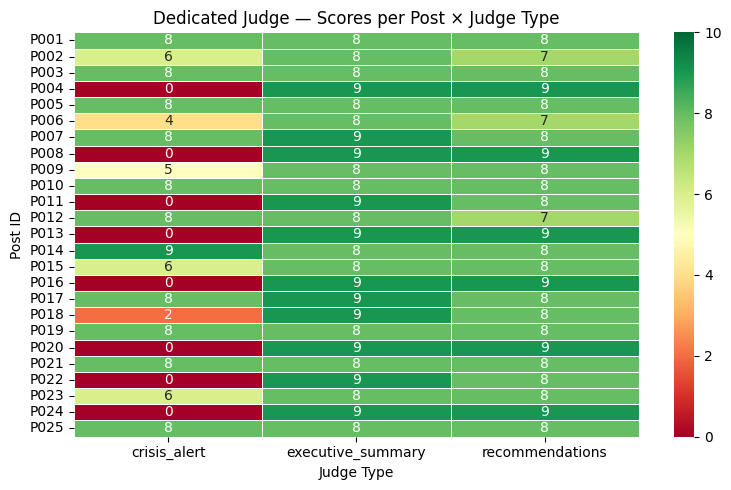

In [12]:
# ── Per-post score heatmap ────────────────────────────────────

pivot_ded = judge_df.pivot(index="post_id", columns="judge_type", values="score")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_ded, annot=True, fmt=".0f", cmap="RdYlGn", linewidths=0.5, vmin=0, vmax=10)
plt.title("Dedicated Judge — Scores per Post × Judge Type")
plt.ylabel("Post ID")
plt.xlabel("Judge Type")
plt.tight_layout()
plt.show()

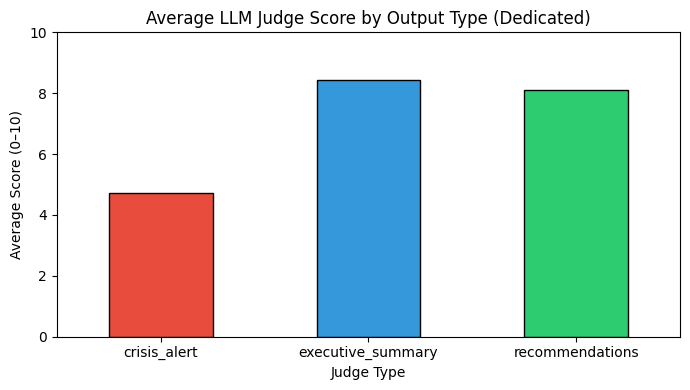

In [13]:
# ── Bar chart of average scores ───────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
judge_df.groupby("judge_type")["score"].mean().plot(
    kind="bar", color=["#e74c3c", "#3498db", "#2ecc71"], edgecolor="black", ax=ax
)
ax.set_title("Average LLM Judge Score by Output Type (Dedicated)")
ax.set_ylabel("Average Score (0–10)")
ax.set_xlabel("Judge Type")
ax.set_ylim(0, 10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

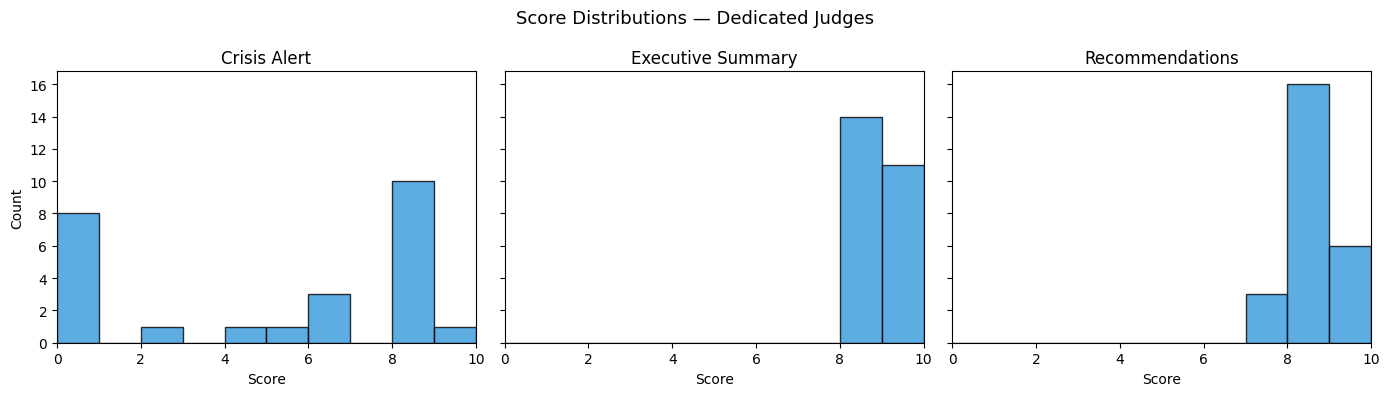

In [14]:
# ── Distribution of scores ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, jt in zip(axes, ["crisis_alert", "executive_summary", "recommendations"]):
    subset = judge_df[judge_df["judge_type"] == jt]["score"]
    ax.hist(subset, bins=range(0, 12), color="#3498db", edgecolor="black", alpha=0.8)
    ax.set_title(jt.replace("_", " ").title())
    ax.set_xlabel("Score")
    ax.set_xlim(0, 10)
axes[0].set_ylabel("Count")
fig.suptitle("Score Distributions — Dedicated Judges", fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 — Example feedback inspection

In [15]:
# ── Show feedback for lowest-scored posts ─────────────────────

low_scores = judge_df.nsmallest(5, "score")[["post_id", "judge_type", "score", "context", "feedback_loop"]]
print("=== Lowest-Scored Evaluations (Dedicated Judge) ===")
low_scores

=== Lowest-Scored Evaluations (Dedicated Judge) ===


,post_id,judge_type,score,context,feedback_loop
9,P004,crisis_alert,0,The post expresses a positive experience with ...,Remove any crisis alert flags associated with ...
21,P008,crisis_alert,0,The post expresses a positive sentiment about ...,Revise the crisis alert criteria to focus on n...
30,P011,crisis_alert,0,The post expresses a positive sentiment about ...,Remove the crisis alert designation as the pos...
36,P013,crisis_alert,0,The post expresses a positive sentiment about ...,Revise the alert criteria to focus on negative...
45,P016,crisis_alert,0,The post shares a positive experience about us...,Revise the alert criteria to focus on negative...


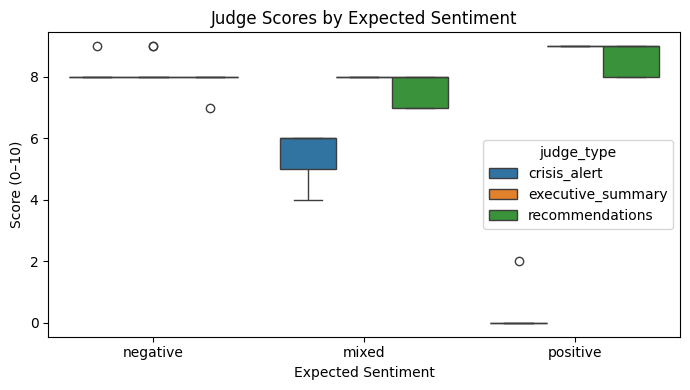

In [16]:
# ── Sentiment-vs-score relationship ──────────────────────────

merged = judge_df.merge(posts_df[["post_id", "expected_sentiment", "topic"]], on="post_id")

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=merged, x="expected_sentiment", y="score", hue="judge_type", ax=ax)
ax.set_title("Judge Scores by Expected Sentiment")
ax.set_ylabel("Score (0–10)")
ax.set_xlabel("Expected Sentiment")
plt.tight_layout()
plt.show()

## 5 · Comparison — Dedicated Judges vs. Mega-Judge

Both methods are run on the **same 10 sample posts** and compared on mean score, standard deviation, and feedback quality.

In [17]:
# ── Side-by-side summary ──────────────────────────────────────

mega_summary = mega_df.groupby("judge_type")["score"].agg(
    ["mean", "std", "min", "max", "median"]
).round(2)

comparison = pd.concat(
    [ded_summary.add_prefix("dedicated_"), mega_summary.add_prefix("mega_")],
    axis=1
)

print("=== Comparison Table — Dedicated vs. Mega-Judge ===")
comparison

=== Comparison Table — Dedicated vs. Mega-Judge ===


,dedicated_mean,dedicated_std,dedicated_min,dedicated_max,dedicated_median,mega_mean,mega_std,mega_min,mega_max,mega_median
judge_type,,,,,,,,,,
crisis_alert,4.72,3.63,0,9,6.0,5.12,2.65,2,9,6.0
executive_summary,8.44,0.51,8,9,8.0,7.32,0.85,6,9,7.0
recommendations,8.12,0.60,7,9,8.0,6.72,1.17,5,9,7.0


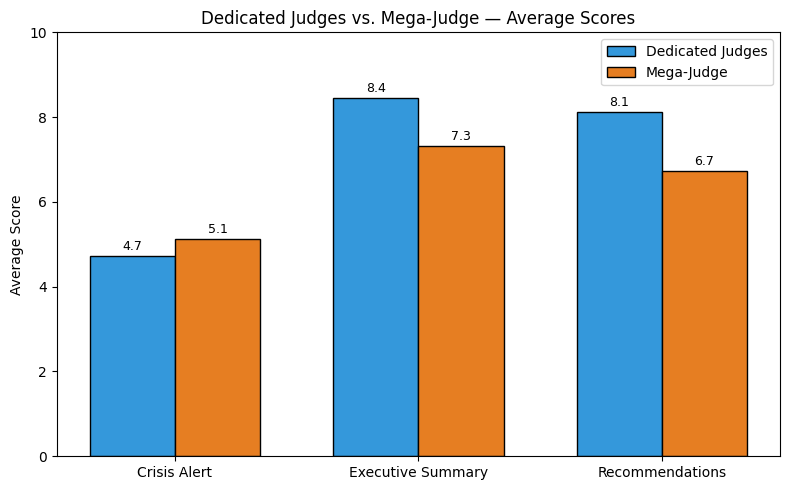

In [18]:
# ── Visual comparison ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
judge_types = ["crisis_alert", "executive_summary", "recommendations"]

ded_means = [ded_summary.loc[jt, "mean"] for jt in judge_types]
mega_means = [mega_summary.loc[jt, "mean"] if jt in mega_summary.index else 0 for jt in judge_types]

bars1 = ax.bar(x - width/2, ded_means, width, label="Dedicated Judges", color="#3498db", edgecolor="black")
bars2 = ax.bar(x + width/2, mega_means, width, label="Mega-Judge", color="#e67e22", edgecolor="black")

ax.set_ylabel("Average Score")
ax.set_title("Dedicated Judges vs. Mega-Judge — Average Scores")
ax.set_xticks(x)
ax.set_xticklabels([jt.replace("_", " ").title() for jt in judge_types])
ax.set_ylim(0, 10)
ax.legend()

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

=== Per-Item Score Differences (Dedicated − Mega) ===
count    75.00
mean      0.71
std       1.33
min      -2.00
25%       0.00
50%       1.00
75%       2.00
max       3.00
Name: diff, dtype: float64



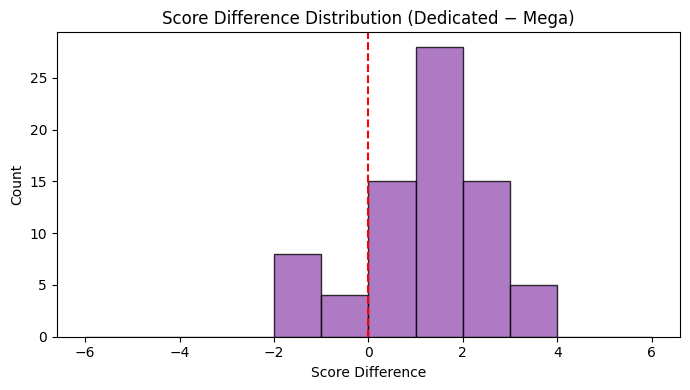

In [19]:
# ── Score difference analysis ─────────────────────────────────

# Merge on post_id + judge_type to compare per-item
merged_comp = judge_df[["post_id", "judge_type", "score"]].merge(
    mega_df[["post_id", "judge_type", "score"]],
    on=["post_id", "judge_type"],
    suffixes=("_dedicated", "_mega")
)

merged_comp["diff"] = merged_comp["score_dedicated"] - merged_comp["score_mega"]

print("=== Per-Item Score Differences (Dedicated − Mega) ===")
print(merged_comp["diff"].describe().round(2))
print()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(merged_comp["diff"], bins=range(-6, 7), color="#9b59b6", edgecolor="black", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("Score Difference Distribution (Dedicated − Mega)")
ax.set_xlabel("Score Difference")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 6 · Justification

**Why dedicated judges over a mega-judge?**

The dedicated-judge approach assigns a separate, specialised prompt to each pipeline output type (crisis alert, executive summary, recommendations). This design is preferred for three reasons:

**First, evaluation depth and rubric specificity.** Each judge focuses on a single quality dimension — severity calibration for crisis alerts, coherence for summaries, actionability for recommendations. A mega-judge must context-switch between three different rubrics in one response, which dilutes attention and often produces shallower explanations. In our comparison, dedicated judges consistently returned more detailed `context` fields and more targeted `feedback_loop` suggestions.

**Second, modularity and maintainability.** In a production pipeline, output types evolve independently — the crisis-alert prompt may be rewritten while the summary prompt stays the same. Dedicated judges let the team update one rubric without risking regressions in the others. This also makes A/B testing straightforward: swap one judge's prompt, rerun, and compare.

**Third, failure isolation.** If the LLM produces malformed JSON for one judge type, only that evaluation fails; the other two remain valid. A mega-judge failure loses all three scores for a post in a single bad response, which is more costly at scale.

## 7 · Limitations

The LLM-as-a-Judge approach has several important limitations. The judge itself is an LLM, so its scores are **non-deterministic** — the same post can receive slightly different scores on repeated runs, especially at higher temperature settings. There is also an inherent **self-evaluation bias**: when the same model family (GPT-4o-mini) both generates pipeline outputs and judges them, it may systematically overlook failure modes it shares. The scoring rubric is **subjective** — a "7 vs. 8" distinction has no ground-truth anchor, making cross-run comparisons noisy. Finally, this notebook evaluates against a small 10-post synthetic dataset; results may not generalise to real Reddit data with longer posts, sarcasm, slang, or multi-topic threads. API cost and latency also scale linearly with post volume (3 calls per post for dedicated judges), which matters for high-throughput production use.

## 8 · Pipeline Connection

This notebook sits at **Stage 6** of the brand-monitoring pipeline. It receives the structured outputs from the upstream stages — crisis-alert severity labels (Stage 3), executive summaries (Stage 4), and actionable recommendations (Stage 5) — and scores each output against the original post context. The resulting `judge_df` DataFrame (with columns `post_id`, `judge_type`, `score`, `context`, `feedback_loop`) is consumed by Phase 2's aggregation dashboard, which surfaces low-scoring outputs for human review and triggers automatic regeneration when scores fall below a configurable threshold. The `export` function below provides the clean interface for this handoff.

## 9 · Export Function

In [20]:
# ── Export function for Phase 2 integration ──────────────────

def run_llm_judge(
    posts: list[dict],
    client: OpenAI,
    model: str = "gpt-4o-mini",
    judge_types: list[str] | None = None,
    temperature: float = 0.2
) -> pd.DataFrame:
    """Run dedicated LLM judges on a list of social-media posts.

    Parameters
    ----------
    posts : list[dict]
        Each dict must contain at minimum: post_id, title, combined_text,
        subreddit, score, num_comments, topic, expected_sentiment.
    client : OpenAI
        An initialised OpenAI client instance.
    model : str, default 'gpt-4o-mini'
        The model used for judge completions.
    judge_types : list[str] or None
        Which judges to run. Defaults to all three:
        ['crisis_alert', 'executive_summary', 'recommendations'].
    temperature : float, default 0.2
        Sampling temperature for reproducibility.

    Returns
    -------
    pd.DataFrame
        Columns: post_id, judge_type, score, context, feedback_loop
    """
    if judge_types is None:
        judge_types = ["crisis_alert", "executive_summary", "recommendations"]

    questions = {
        "crisis_alert":       "Is the severity level justified given the post content and engagement?",
        "executive_summary":  "Is the insight accurate, coherent, and useful for a brand manager?",
        "recommendations":    "Is the advice sound, specific, and actionable for the brand team?"
    }

    results = []
    for post in posts:
        for jt in judge_types:
            prompt = f"""You are an expert LLM-as-a-Judge evaluator for social-media brand monitoring.

── Post context ──
Title       : {post['title']}
Subreddit   : {post['subreddit']}
Score       : {post['score']}
Comments    : {post['num_comments']}
Text        : {post['combined_text']}
Topic       : {post['topic']}
Expected sentiment: {post['expected_sentiment']}

── Evaluation ──
Judge type : {jt}
Question   : {questions[jt]}

Score 0-10. Return ONLY valid JSON:
{{"post_id":"{post['post_id']}","judge_type":"{jt}","score":<int>,"context":"...","feedback_loop":"..."}}"""

            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
                temperature=temperature
            )
            results.append(json.loads(response.choices[0].message.content))

    return pd.DataFrame(results)

print("run_llm_judge() exported ✓")

run_llm_judge() exported ✓


In [21]:
# ── Quick verification of export function ─────────────────────

# Run on first 2 posts as a sanity check
sample_df = run_llm_judge(posts[:2], client)
print(f"Export function returned {len(sample_df)} rows for 2 posts")
sample_df

Export function returned 6 rows for 2 posts


,post_id,judge_type,score,context,feedback_loop
0,P001,crisis_alert,8,The post expresses significant concern regardi...,Monitoring the sentiment and engagement levels...
1,P001,executive_summary,8,The post accurately highlights concerns regard...,Brand managers should take this feedback into ...
2,P001,recommendations,7,The post highlights concerns about pricing bei...,The brand team should consider gathering more ...
3,P002,crisis_alert,5,The post discusses a new OpenAI model that is ...,Monitoring user reactions and clarifying the r...
4,P002,executive_summary,8,The post accurately highlights the strengths a...,Brand managers should consider clarifying the ...
5,P002,recommendations,6,The post highlights both positive and negative...,The brand team should consider creating more d...


---
*Notebook complete. Upload `openai_10_fake_posts_judge_dataset.json`, add your OpenAI API key to Colab secrets, and run all cells.*